# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Load Dataset

In [2]:
df = pd.read_csv("/content/comic_books_10000_dataset.csv")

df.head()

,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,890,8.0,Ongoing,Japanese,Mature,NaN,13
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,2850,8.3,Completed,Japanese,Mature,NaN,12
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,350,7.8,Ongoing,English,Teen+,Japan Media Arts Award Winner,13
3,CMC-00004,Abyss Destiny,Yuna Yamaguchi,Yuna Yamaguchi,Kodansha (Kodansha USA),2014,Manga Volume,Black & White,Slice of Life / Drama,Japan,592,8.7,Cancelled,Japanese,Teen+,Eisner Award Nominee,13
4,CMC-00005,After Smoke,Shannon Watters,Warren Ellis,Kodansha Comics,2005,OGN,Black & White,Romance / Drama,USA,2465,7.0,Ongoing,English,Mature,NaN,4


# ตรวจข้อมูล

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   comic_id             10000 non-null  object 
 1   Title                10000 non-null  object 
 2   Writer               10000 non-null  object 
 3   Artist               10000 non-null  object 
 4   Studio/Publisher     10000 non-null  object 
 5   Release Year         10000 non-null  int64  
 6   Format               10000 non-null  object 
 7   Theme (Color Style)  10000 non-null  object 
 8   Genre                10000 non-null  object 
 9   Country of Origin    10000 non-null  object 
 10  Page Count           10000 non-null  int64  
 11  Rating (out of 10)   10000 non-null  float64
 12  Status               10000 non-null  object 
 13  Language             10000 non-null  object 
 14  Age Rating           10000 non-null  object 
 15  Awards               3984 non-null   

,Release Year,Page Count,Rating (out of 10),Volume Count
count,10000.000000,10000.000000,10000.000000,10000.00000
mean,2015.495900,2232.871200,8.057100,13.67150
std,7.438381,1866.722721,0.533893,11.36466
min,2000.000000,48.000000,6.000000,1.00000
25%,2010.000000,748.750000,7.700000,5.00000
50%,2017.000000,1571.000000,8.100000,10.00000
75%,2022.000000,3511.000000,8.400000,19.00000
max,2026.000000,14400.000000,9.900000,56.00000


# Data Preprocessing
# เลือก Feature ที่ใช้

In [ ]:
df = df[['Release Year','Page Count','Volume Count','Genre',
         'Country of Origin','Format','Language','Status','Age Rating']]

# ลบ Missing Value

In [ ]:
df = df.dropna()

# Exploratory Data Analysis (EDA)
# ดู Distribution ของ Age Rating

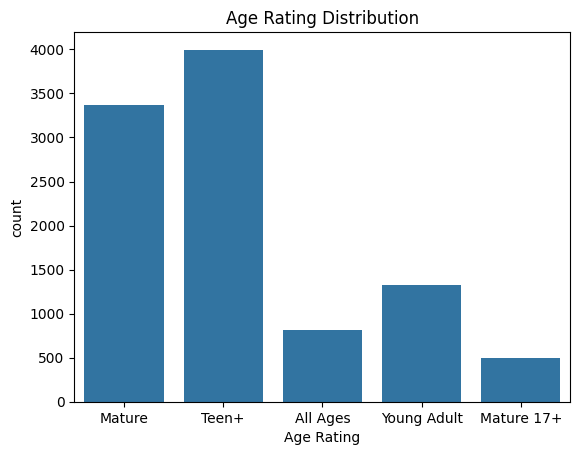

In [ ]:
sns.countplot(x='Age Rating', data=df)
plt.title("Age Rating Distribution")
plt.show()

# ดู Genre ที่พบมาก

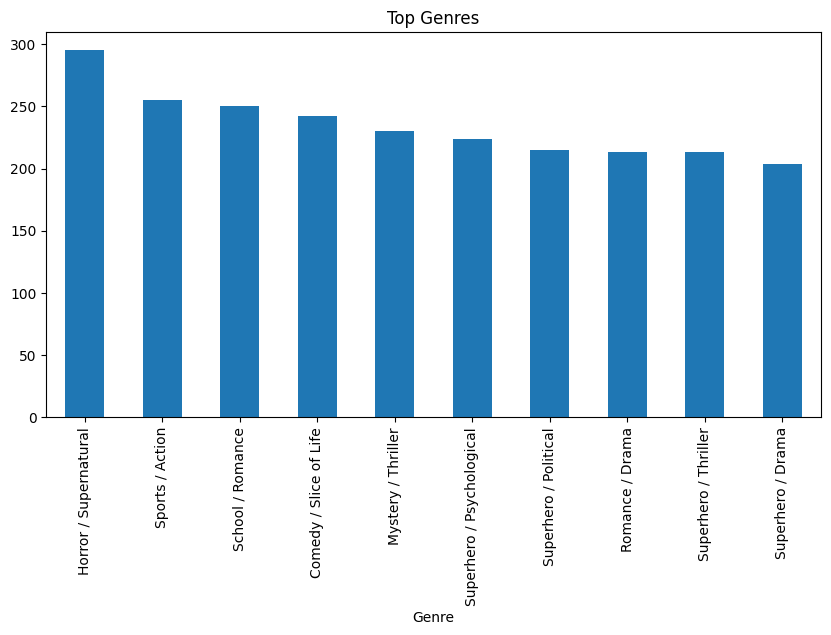

In [ ]:
plt.figure(figsize=(10,5))
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

# Correlation

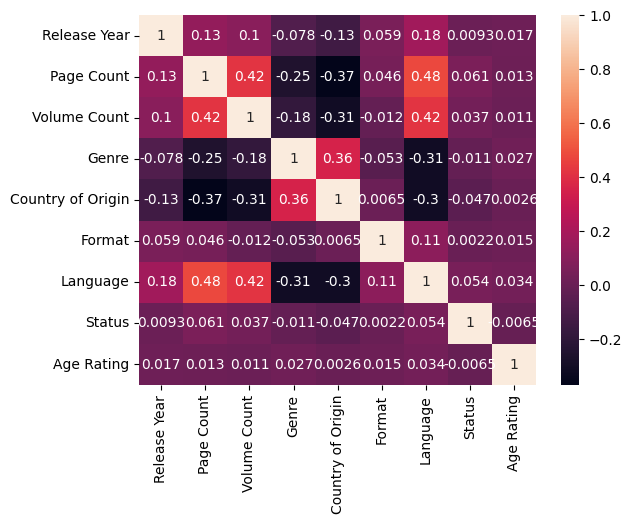

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()

# Encode ข้อมูล

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Split Data

In [ ]:
X = df.drop("Age Rating", axis=1)
y = df["Age Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Machine Learning Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(name, "Accuracy =", acc)

Logistic Regression Accuracy = 0.42
Decision Tree Accuracy = 0.297
Random Forest Accuracy = 0.388
KNN Accuracy = 0.3415
SVM Accuracy = 0.409


# Model Comparison

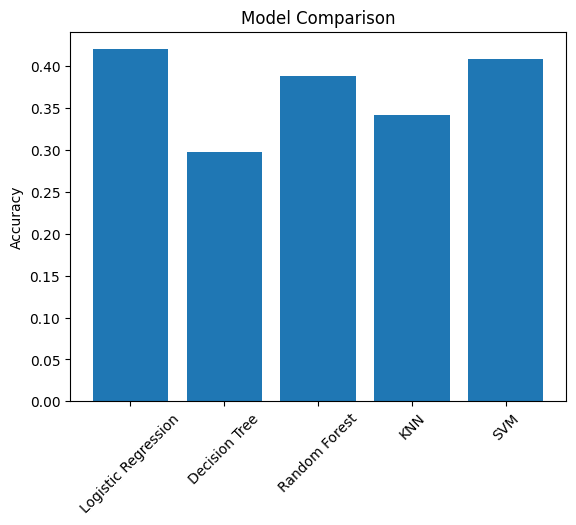

In [ ]:
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

# Best Model

In [ ]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


# ใช้โมเดลที่ดีที่สุด

In [ ]:
best_model = models[best_model_name]

# Confusion Matrix

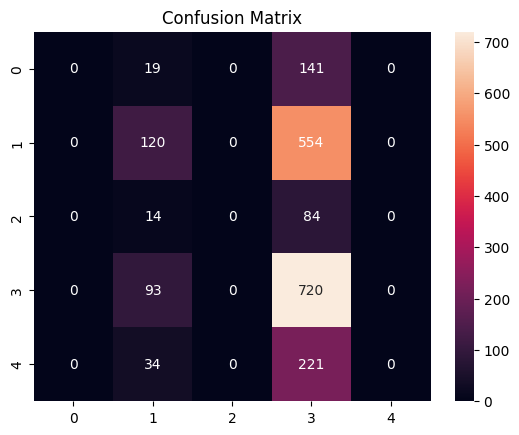

In [ ]:
pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       160
           1       0.43      0.18      0.25       674
           2       0.00      0.00      0.00        98
           3       0.42      0.89      0.57       813
           4       0.00      0.00      0.00       255

    accuracy                           0.42      2000
   macro avg       0.17      0.21      0.16      2000
weighted avg       0.31      0.42      0.32      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


# Feature Importance

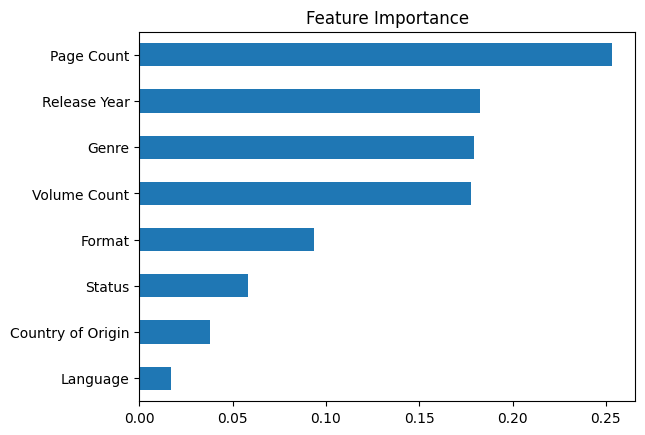

In [ ]:
importance = model.feature_importances_
feat_importance = pd.Series(importance, index=X.columns)

feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, max_depth=10)

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.39049999999999996
